In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from CreateAnatomy import create_anatomy
from shapely.geometry import Polygon
from scipy.spatial import Voronoi
import warnings



# Modules
from ReadXML import ReadXML
from CellLayers import cell_layer
from CreateCells import create_cells
from LayerInfo import layer_info
from MakePith import make_pith
from RondyCortex import rondy_cortex
from Vascular import vascular
from PackXylem import pack_xylem
from CellVoronoi import cell_voro
from SmoothyCells import smoothy_cells
from FuzzeInter import fuzze_inter
from Aerenchyma import aerenchyma
from Septa import septa
from RootHair import root_hair
from ClearNodes import clear_nodes
from Vertex import vertex
from DetailedGraph import create_detailed_graph
from utils import get_val

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
# 1. Define Parameters (GRANAR Format)
params_data = [
    {"name": "planttype", "type": "value", "value": 1}, # 1 = Monocot, 2 = Dicot
    {"name": "randomness", "type": "value", "value": 0}, # 0 = No randomness, 3 = Maximum randomness
    {"name": "secondarygrowth", "type": "value", "value": 0},
    {"name": "stele", "type": "cell_diameter", "value": 0.0063}, # Cell diameter in millimeters
    {"name": "stele", "type": "layer_diameter", "value": 0.163}, # Layer diameter in millimeters
    {"name": "stele", "type": "n_layers", "value": 1}, # Layer diameter in millimeters
    {"name": "stele", "type": "order", "value": 1}, # Order of the stele
    {"name": "pericycle", "type": "cell_diameter", "value": 0.009},
    {"name": "pericycle", "type": "n_layers", "value": 1},
    {"name": "pericycle", "type": "order", "value": 2},
    {"name": "endodermis", "type": "cell_diameter", "value": 0.015},
    {"name": "endodermis", "type": "n_layers", "value": 1},
    {"name": "endodermis", "type": "order", "value": 3},
    {"name": "innercortex", "type": "cell_diameter", "value": 0.017},
    {"name": "innercortex", "type": "n_layers", "value": 2},
    {"name": "innercortex", "type": "order", "value": 4},
    {"name": "cortex", "type": "cell_diameter", "value": 0.025},
    {"name": "cortex", "type": "n_layers", "value": 3},
    {"name": "cortex", "type": "order", "value": 5},
    {"name": "outercortex", "type": "cell_diameter", "value": 0.01},
    {"name": "outercortex", "type": "n_layers", "value": 2},
    {"name": "outercortex", "type": "order", "value": 6},
    {"name": "exodermis", "type": "cell_diameter", "value": 0.018},
    {"name": "exodermis", "type": "n_layers", "value": 1},
    {"name": "exodermis", "type": "order", "value": 7},
    {"name": "epidermis", "type": "cell_diameter", "value": 0.006},
    {"name": "epidermis", "type": "n_layers", "value": 1},
    {"name": "epidermis", "type": "order", "value": 8},
    {"name": "xylem", "type": "n_files", "value": 5}, # Number of files
    {"name": "xylem", "type": "max_size", "value": 0.035}, # Maximum size in millimeters
    {"name": "xylem", "type": "order", "value": 1.5}, # Order of the xylem
    {"name": "xylem", "type": "ratio", "value": 3.3}, # Ratio of the xylem
    {"name": "phloem", "type": "n_files", "value": 3}, # Number of files
    {"name": "phloem", "type": "max_size", "value": 0.01}, # Maximum size in millimeters
    {"name": "phloem", "type": "n_layers", "value": 0}, # Ratio of the phloem
    {"name": "aerenchyma", "type": "proportion", "value": 0},
    {"name": "aerenchyma", "type": "n_files", "value": 0},
    {"name": "aerenchyma", "type": "type", "value": 1}, # 1 = Strip, 2 = Fused
    {"name": "inter_cellular_space", "type": "ratio", "value": 0.01},
    {"name": "inter_cellular_space", "type": "size", "value": 0.002},
    {"name": "hair", "type": "n_files", "value": 10},
    {"name": "hair", "type": "length", "value": 0.07},
    {"name": "pith", "type": "layer_diameter", "value": 0.03},
    {"name": "pith", "type": "cell_diameter", "value": 0.01}
]
params = pd.DataFrame(params_data)
verbatim = True
def get_val(params: pd.DataFrame, name: str, ptype: str) -> float:
    v = params[(params['name'] == name) & (params['type'] == ptype)]['value']
    return v.iloc[0] if not v.empty else 0


In [50]:
# 2. Setup
random_fact = get_val(params, "randomness", "value") / 10 * get_val(params, "stele", "cell_diameter") 
if random_fact == 0: random_fact = get_val(params, "randomness", "value")

proportion_aerenchyma = get_val(params, "aerenchyma", "proportion")

# 3. Cell Layers
layers = cell_layer(params) # Seems ok
all_layers = layer_info(layers, params)
center = all_layers['radius'].max()


stele
0.0063
0.0
0.0063
0.0063
stele
0.0126
0.0063
0.0063
0.0063
stele
0.0189
0.0126
0.0063
0.0063
stele
0.0252
0.0189
0.0063
0.0063
stele
0.0315
0.0252
0.0063
0.0063
stele
0.0378
0.0315
0.0063
0.0063
stele
0.0441
0.0378
0.0063
0.0063
stele
0.0504
0.0441
0.0063
0.0063
stele
0.0567
0.0504
0.0063
0.0063
stele
0.063
0.0567
0.0063
0.0063
stele
0.0693
0.063
0.0063
0.0063
stele
0.0756
0.0693
0.0063
0.0063
pericycle
0.08325
0.0756
0.0063
0.009
endodermis
0.09525
0.08325
0.009
0.015
innercortex
0.11125000000000002
0.09525
0.015
0.017
innercortex
0.12825000000000003
0.11125000000000002
0.017
0.017
cortex
0.14925000000000005
0.12825000000000003
0.017
0.025
cortex
0.17425000000000007
0.14925000000000005
0.025
0.025
cortex
0.1992500000000001
0.17425000000000007
0.025
0.025
outercortex
0.2167500000000001
0.1992500000000001
0.025
0.01
outercortex
0.22675000000000012
0.2167500000000001
0.01
0.01
exodermis
0.24075000000000013
0.22675000000000012
0.01
0.018
epidermis
0.25275000000000014
0.2407500000000

In [51]:
print(all_layers)

           name  cell_diameter  n_layers  order   radius     perim  n_cell  \
0         stele         0.0063      13.0    1.0  0.00000  0.019792       1   
1         stele         0.0063      13.0    1.0  0.00630  0.039584       6   
2         stele         0.0063      13.0    1.0  0.01260  0.079168      13   
3         stele         0.0063      13.0    1.0  0.01890  0.118752      19   
4         stele         0.0063      13.0    1.0  0.02520  0.158336      25   
5         stele         0.0063      13.0    1.0  0.03150  0.197920      31   
6         stele         0.0063      13.0    1.0  0.03780  0.237504      38   
7         stele         0.0063      13.0    1.0  0.04410  0.277088      44   
8         stele         0.0063      13.0    1.0  0.05040  0.316673      50   
9         stele         0.0063      13.0    1.0  0.05670  0.356257      57   
10        stele         0.0063      13.0    1.0  0.06300  0.395841      63   
11        stele         0.0063      13.0    1.0  0.06930  0.4354

In [25]:
test = layer_info

In [53]:
# 4. Create Initial Cells
all_cells = create_cells(all_layers, random_fact)
if verbatim:
    print("Initial Cell Counts:")
    print(all_cells['type'].value_counts())
# Initial cell ID group
all_cells['id_group'] = 0

print(all_cells)

Initial Cell Counts:
type
outside        554
stele          491
outercortex    282
epidermis      268
cortex         133
innercortex     90
exodermis       85
pericycle       60
endodermis      41
Name: count, dtype: int64
         angle  radius         x         y  id_layer  id_cell     type  order  \
0     0.000000  0.0000  0.267500  0.267500         1        1    stele    1.0   
1     1.047198  0.0063  0.270650  0.272956         2        2    stele    1.0   
2     2.094395  0.0063  0.264350  0.272956         2        3    stele    1.0   
3     3.141593  0.0063  0.261200  0.267500         2        4    stele    1.0   
4     4.188790  0.0063  0.264350  0.262044         2        5    stele    1.0   
...        ...     ...       ...       ...       ...      ...      ...    ...   
1999  6.193426  0.2675  0.533923  0.243521        26     2000  outside    9.0   
2000  6.215865  0.2675  0.534394  0.249506        26     2001  outside    9.0   
2001  6.238305  0.2675  0.534731  0.255499      

In [32]:
# 5. Internal Structures
if get_val(params, "pith", "layer_diameter") > 0:
    all_cells = make_pith(all_cells, params, center)
    
if get_val(params, "inter_cellular_space", "size") > 0 or get_val(params, "inter_cellular_space", "value") > 0:
    all_cells = rondy_cortex(params, all_cells, center)
    
if verbatim: print("Add vascular elements")
sec_growth = get_val(params, "secondarygrowth", "value")

if sec_growth == 0: 
    all_cells = vascular(all_cells, params, layers, center)
elif sec_growth == 1:
    packing = pack_xylem(all_cells, params, center)
    rm_stele = all_cells[all_cells['type'] != 'stele']
    all_cells = pd.concat([packing, rm_stele], ignore_index=True)
    all_cells['id_cell'] = range(1, len(all_cells) + 1)
    
if verbatim:
    print(f"Cells after vascular: {len(all_cells)}")
    print(all_cells['type'].value_counts())


Add vascular elements
Cells after vascular: 4136
type
cortex                  2394
outside                  554
outercortex              282
epidermis                268
stele                    200
xylem                     96
innercortex               90
exodermis                 85
pericycle                 60
endodermis                41
companion_cell            32
inter_cellular_space      18
phloem                    16
Name: count, dtype: int64


In [33]:
# 6. Voronoi Tesselation
points = all_cells[['x', 'y']].values
vor = Voronoi(points)

voro_out = cell_voro(all_cells, vor, center)
all_cells = voro_out['all_cells']
rs2 = voro_out['rs2']

if verbatim:
    print(f"rs2 (Voronoi edges) count: {len(rs2)}")
    if len(rs2) > 0:
        print(f"rs2 types: {rs2['type'].value_counts() if 'type' in rs2 else 'No type col'}")

rs1 = rs2.copy()
if len(rs1) == 0:
    print("WARNING: rs1 is empty after Voronoi.")

rs1_grouped = rs1.groupby('id_cell').agg({'x': 'mean', 'y': 'mean'}).rename(columns={'x': 'mx', 'y': 'my'})
rs1 = rs1.merge(rs1_grouped, on='id_cell')
rs1['atan'] = np.arctan2(rs1['y'] - rs1['my'], rs1['x'] - rs1['mx'])
rs1 = rs1.sort_values(by=['id_cell', 'atan'])
rs1['id_point'] = rs1['x'].astype(str) + ";" + rs1['y'].astype(str)

rs2 (Voronoi edges) count: 35004
rs2 types: type
cortex                  19810
outercortex              3706
epidermis                2862
stele                    2496
exodermis                1504
innercortex              1410
xylem                    1042
pericycle                 692
endodermis                532
inter_cellular_space      382
companion_cell            372
phloem                    196
Name: count, dtype: int64


In [34]:
# 7. Smoothing and Merging
if verbatim: print("Smooth edge of large cells")
rs1 = smoothy_cells(rs1)
if verbatim: 
    print(f"After smoothing - unique types: {rs1['type'].unique()}")

if verbatim: print("Merging inter cellular space")
rs1 = fuzze_inter(rs1)
if verbatim:
    print(f"After fuzze_inter - unique types: {rs1['type'].unique()}")

Smooth edge of large cells
After smoothing - unique types: ['stele' 'companion_cell' 'phloem' 'xylem' 'pericycle' 'endodermis'
 'innercortex' 'outercortex' 'exodermis' 'epidermis'
 'inter_cellular_space' 'cortex']
Merging inter cellular space
After fuzze_inter - unique types: ['stele' 'companion_cell' 'phloem' 'xylem' 'pericycle' 'endodermis'
 'innercortex' 'outercortex' 'exodermis' 'epidermis'
 'inter_cellular_space' 'cortex']


In [35]:
# 8. Aerenchyma
if proportion_aerenchyma > 0:
    rs1 = clear_nodes(rs1)
    if verbatim:
        print(f"After clear_nodes (pre-aerenchyma) - unique types: {rs1['type'].unique()}")
    if verbatim: print("fusing cells for aerenchyma")
    rs1 = aerenchyma(params, rs1)
    if verbatim:
        print(f"After aerenchyma - unique types: {rs1['type'].unique()}")
    if verbatim: print("simplify septa")
    rs1 = septa(rs1)
    if verbatim:
        print(f"After septa - unique types: {rs1['type'].unique()}")

In [36]:
# 9. Root Hair
if get_val(params, "hair", "n_files") > 0:
    if verbatim: print("Add root hair")
    rs1 = root_hair(rs1, params, center)
    if verbatim:
        print(f"After root_hair - unique types: {rs1['type'].unique()}")
    

Add root hair
After root_hair - unique types: ['stele' 'companion_cell' 'phloem' 'xylem' 'pericycle' 'endodermis'
 'innercortex' 'outercortex' 'exodermis' 'epidermis'
 'inter_cellular_space' 'cortex']


In [37]:
# 10. Final Cleanup
rs1 = clear_nodes(rs1)
if verbatim:
    print(f"After final clear_nodes - unique types: {rs1['type'].unique()}")

After final clear_nodes - unique types: ['stele' 'companion_cell' 'phloem' 'xylem' 'pericycle' 'endodermis'
 'innercortex' 'outercortex' 'exodermis' 'epidermis'
 'inter_cellular_space' 'cortex']


In [38]:
ptype = get_val(params, "planttype", "value")
if ptype == 1:
    x_cells = rs1[rs1['type'] == 'xylem']
    if not x_cells.empty: # Avoid error if empty
        # Recalculate areas to be safe
        tmp_poly_areas = {}
        for cid, grp in rs1.groupby('id_cell'):
            if len(grp) >= 3:
                    try:
                        poly = Polygon(zip(grp['x'], grp['y']))
                        tmp_poly_areas[cid] = poly.area
                    except:
                        tmp_poly_areas[cid] = 0
            
        rs1['area'] = rs1['id_cell'].map(tmp_poly_areas)
            
        x_cells = rs1[rs1['type'] == 'xylem']
        if not x_cells.empty:
            mean_area = x_cells.drop_duplicates('id_cell')['area'].mean()
            large_xylem = x_cells[x_cells['area'] > mean_area]['id_cell'].unique()
            rs1.loc[(rs1['type'] == 'xylem') & (rs1['id_cell'].isin(large_xylem)), 'type'] = 'metaxylem'
        
if get_val(params, "epidermis", "remove") == 1:
    rs1 = rs1[rs1['type'] != 'epidermis']

In [39]:
# 11. Create NetworkX Graph
if verbatim: print("Building Detailed NetworkX Graph with Cells, Walls, and Junctions...")

# Pre-calculate polygons and attach to rs1
# Create a unique dataframe for cells (one row per cell)
cells_data = []

for cid, grp in rs1.groupby('id_cell'):
    if len(grp) >= 3:
        pts = list(zip(grp['x'], grp['y']))
        poly = Polygon(pts)
        if not poly.is_valid:
            poly = poly.buffer(0)
        
        # Get attributes from first row of group
        first = grp.iloc[0]
        cells_data.append({
            'id_cell': cid,
            'type': first['type'],
            'x': poly.centroid.x,
            'y': poly.centroid.y,
            'area': poly.area,
            'geometry': poly
        })

Building Detailed NetworkX Graph with Cells, Walls, and Junctions...


In [40]:
# Convert to GeoDataFrame for spatial operations
import geopandas as gpd
cells_gdf = gpd.GeoDataFrame(cells_data, geometry='geometry', crs=None)

# Build Detailed Graph using GeoDataFrame
G = create_detailed_graph(cells_gdf, None)

Building detailed graph from 1245 cells...
DEBUG: Processed 6794 polygon edges. Found 2521 shared walls (reuse events).
Detailed Graph created:
- Cells: 1245
- Junctions: 2724
- Walls: 4273



Step 2: Plotting the graph...


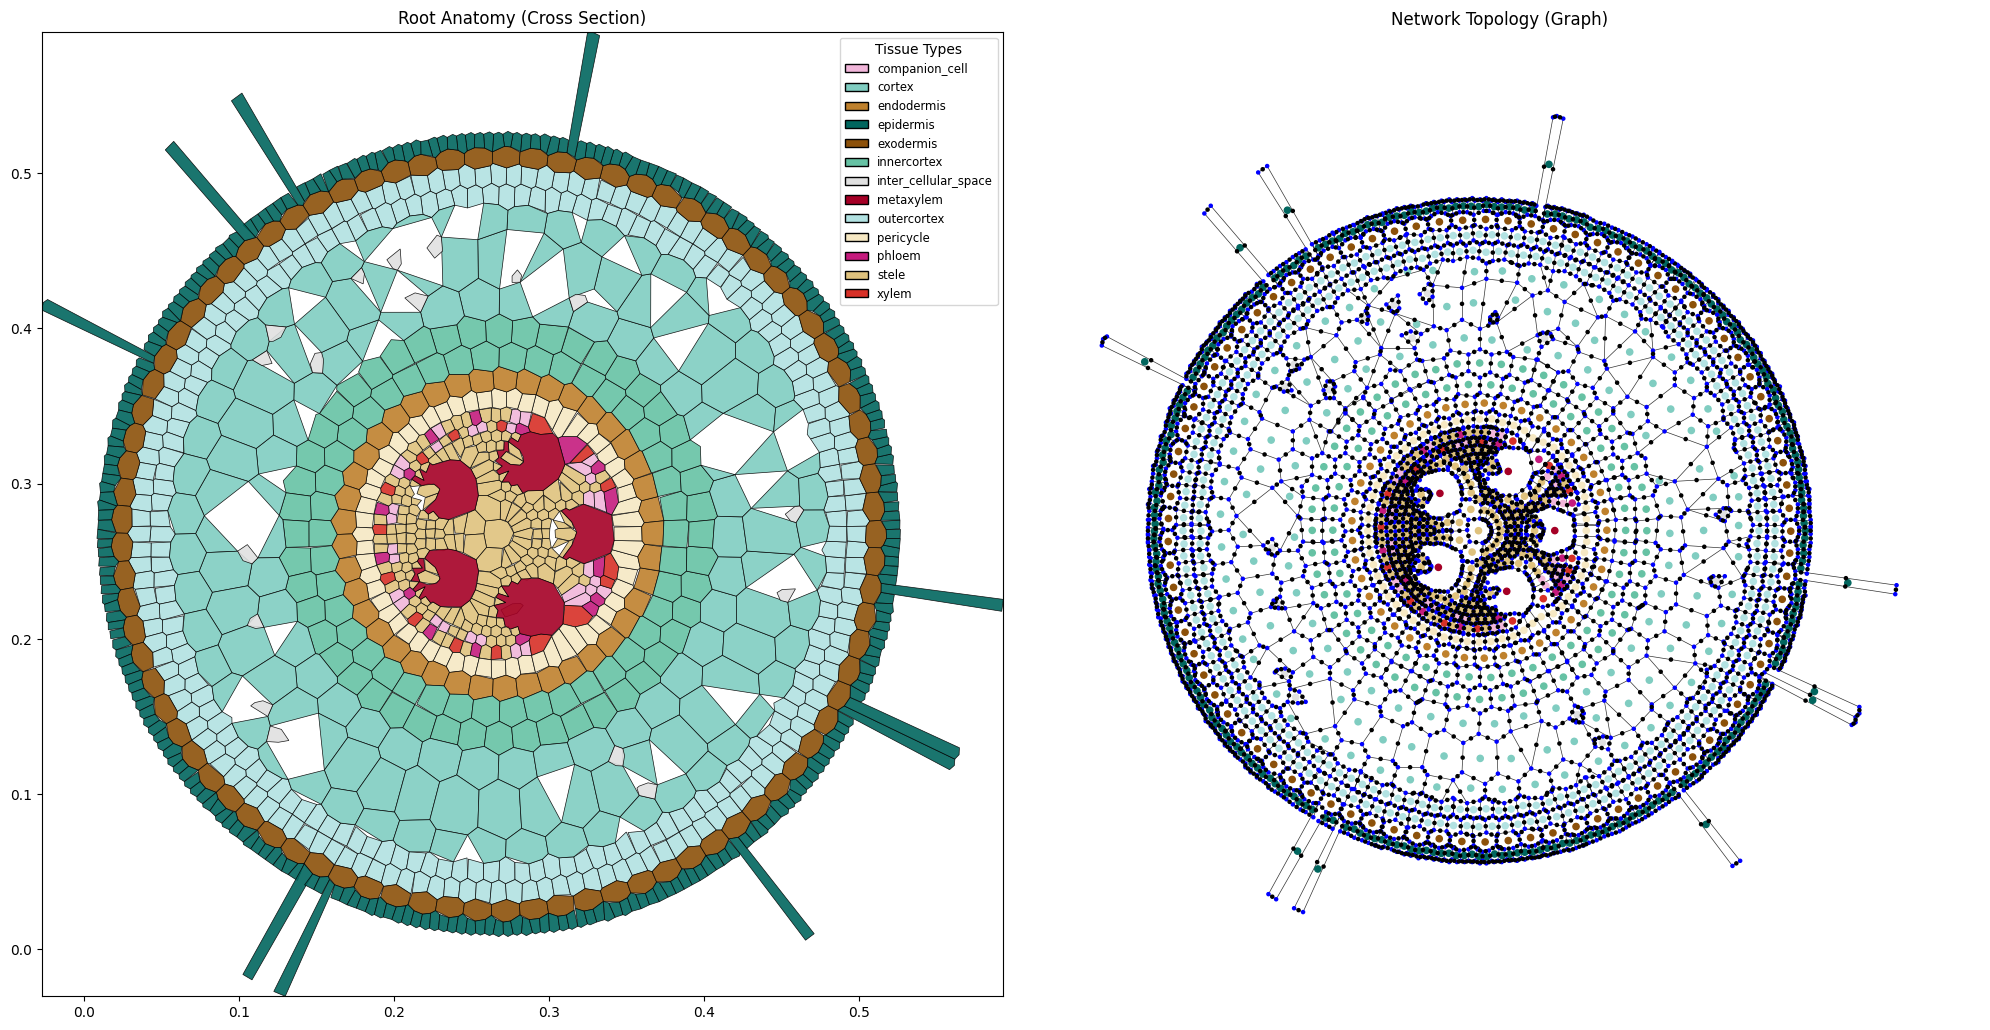

In [41]:
print("\nStep 2: Plotting the graph...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Get positions (Handle both schemes)
pos = {}
for n, d in G.nodes(data=True):
    x = d.get('x', d.get('center_x', 0))
    y = d.get('y', d.get('center_y', 0))
    pos[n] = (x, y)


# Get colors based on type
unique_types = set(d.get('type', 'unknown') for n, d in G.nodes(data=True))

# Fixed Color Map - Comprehensive tissue types
color_map = {
    # Central tissues
    'stele': '#dfc27d',
    'parenchyma': '#f5deb3',  # Wheat color for parenchyma
    'pericycle': '#f6e8c3',
    
    # Vascular
    'xylem': '#d73027',
    'metaxylem': '#a50026',
    'protoxylem': '#fc8d59',
    'phloem': '#c51b7d',
    'companion_cell': '#f1b6da',
    
    # Endodermis
    'endodermis': '#bf812d',
    
    # Cortex layers (gradient from inner to outer)
    'innercortex': '#66c2a4',    # Teal-green
    'cortex': '#80cdc1',          # Light teal
    'outercortex': '#b2e2e2',    # Pale teal
    
    # Outer layers
    'exodermis': '#8c510a',       # Brown
    'epidermis': '#01665e',       # Dark teal
    
    # Special structures
    'inter_cellular_space': '#e0e0e0',
    'aerenchyma': '#a6cee3',
    'outside': '#ffffff',
    'pith': '#dfc27d',
    
    # Graph structure nodes
    'wall': 'black',
    'junction': 'blue'
}

# Fallback for any unknown types
for t in unique_types:
    if t not in color_map:
        # Use hash to get consistent color for unknown types
        import hashlib
        hash_object = hashlib.md5(str(t).encode())
        hex_color = '#' + hash_object.hexdigest()[:6]
        color_map[t] = hex_color


node_colors = [color_map.get(d.get('type', 'unknown'), 'gray') for n, d in G.nodes(data=True)]

# Determine node sizes
node_sizes = []
for n, d in G.nodes(data=True):
    ctype = d.get('type')
    if ctype == 'junction':
        node_sizes.append(5)
    elif ctype == 'wall':
        node_sizes.append(5)
    else:
        node_sizes.append(20) # Cells big

# --- PLOT 1: ANATOMY (Polygons) ---
ax1.set_title("Root Anatomy (Cross Section)")
ax1.set_aspect('equal')

from matplotlib.patches import Polygon as MplPolygon
from shapely.geometry import Polygon as ShapelyPolygon, MultiPolygon

for n, d in G.nodes(data=True):
    # Only plot cells with geometry
    if 'geometry' in d and d['geometry'] is not None:
        geom = d['geometry']
        color = color_map.get(d['type'], 'gray')
        
        # Helper to add patch
        def add_poly_patch(p_geom, ax):
            x, y = p_geom.exterior.xy
            coords = list(zip(x, y))
            poly_patch = MplPolygon(coords, facecolor=color, edgecolor='black', linewidth=0.5, alpha=0.9)
            ax.add_patch(poly_patch)

        if isinstance(geom, ShapelyPolygon):
            add_poly_patch(geom, ax1)
        elif isinstance(geom, MultiPolygon):
            for poly in geom.geoms:
                add_poly_patch(poly, ax1)

# Auto-scale anatomy plot
all_points = []
for n, d in G.nodes(data=True):
    if 'geometry' in d and d['geometry'] is not None:
            geom = d['geometry']
            if isinstance(geom, ShapelyPolygon):
                all_points.extend(geom.envelope.exterior.coords)
            elif isinstance(geom, MultiPolygon):
                all_points.extend(geom.envelope.exterior.coords) # Approximate
                
if len(all_points) > 0:
    pts = np.array(all_points)
    ax1.set_xlim(pts[:,0].min(), pts[:,0].max())
    ax1.set_ylim(pts[:,1].min(), pts[:,1].max())

# Add Legend
from matplotlib.patches import Patch
# Filter types for legend (only tissue types)
legend_types = [t for t in unique_types if t not in ['wall', 'junction']]
legend_elements = [Patch(facecolor=color_map[t], edgecolor='black', label=t) for t in sorted(legend_types)]
ax1.legend(handles=legend_elements, loc='upper right', title="Tissue Types", fontsize='small')

# --- PLOT 2: NETWORK TOPOLOGY (Nodes + Edges) ---
ax2.set_title("Network Topology (Graph)")

# Filter Edges: Only draw 'wall_structure' edges (Wall <-> Junction)
wall_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('type') == 'wall_structure']

# Draw Edges
nx.draw_networkx_edges(G, pos, ax=ax2, edgelist=wall_edges, edge_color='black', width=0.5, alpha=0.8)

# Draw Nodes: Filter to show only Wall/Junction nodes if we are focusing on walls?
# Or keep all nodes but only wall edges?
# User said "just keep the edge between wall".
# I'll keep nodes for now but maybe make non-wall nodes smaller or invisible?
# For now, drawing all nodes as configured previously (Junction/Wall small, Cell big).
nx.draw_networkx_nodes(G, pos, ax=ax2, node_size=node_sizes, node_color=node_colors)

ax2.set_aspect('equal')
ax2.axis('off')

plt.tight_layout()
plt.show()

In [42]:
print(all_cells)


         angle   radius         x         y  id_layer  id_cell   type  order  \
0     0.000000  0.00000  0.267500  0.267500       1.0        1  stele    0.5   
1     0.330694  0.01890  0.284951  0.274084       4.0        2  stele    1.0   
2     0.661388  0.01890  0.282009  0.279257       4.0        3  stele    1.0   
3     0.992082  0.01890  0.277915  0.283498       4.0        4  stele    1.0   
4     1.322776  0.01890  0.271922  0.285687       4.0        5  stele    1.0   
...        ...      ...       ...       ...       ...      ...    ...    ...   
4131  5.026548  0.04865  0.277176  0.208297      20.0     4132  xylem    1.5   
4132  5.026548  0.04865  0.282534  0.207231      20.0     4133  xylem    1.5   
4133  5.026548  0.04865  0.287891  0.208297      20.0     4134  xylem    1.5   
4134  5.026548  0.04865  0.292433  0.211332      20.0     4135  xylem    1.5   
4135  5.026548  0.04865  0.295468  0.215874      20.0     4136  xylem    1.5   

      id_group  d_bound      dist      